# 01 - Analise Exploratoria de Vendas de Produtos

Este notebook faz a primeira leitura analitica da base `product_sales_dataset.csv` com foco em tres objetivos:

1. entender qualidade, estrutura e comportamento da base;
2. definir KPIs relevantes para uma futura aplicacao de monitoramento de vendas;
3. levantar sinais uteis para previsao de vendas e recomendacao de produtos.

A analise combina estatisticas descritivas, cortes por tempo, produto, categoria e cidade, alem de validacoes de consistencia transacional.

## 1. Setup

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titleweight"] = "bold"

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "product_sales_dataset.csv"
DATA_PATH

WindowsPath('C:/Users/vinicius/Documents/Projetos/Product_sales_analysis/data/raw/product_sales_dataset.csv')

## 2. Carga e primeira leitura

In [2]:
df_raw = pd.read_csv(DATA_PATH)
df_raw.head()

,Product_ID,Product_Name,Category,Price_USD,Quantity_Sold,Total_Sales_USD,Order_Date,Customer_City
0,1001,Lipstick,Beauty,26,7,182,2025-01-24,Karachi
1,1002,Jacket,Fashion,254,6,1524,2026-04-01,Peshawar
2,1003,Gym Gloves,Sports,30,10,300,2025-11-05,Peshawar
3,1004,History Book,Books,45,6,270,2026-01-05,Lahore
4,1005,Tennis Ball,Sports,401,1,401,2025-11-28,Quetta


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Product_ID       1000 non-null   int64 
 1   Product_Name     1000 non-null   object
 2   Category         1000 non-null   object
 3   Price_USD        1000 non-null   int64 
 4   Quantity_Sold    1000 non-null   int64 
 5   Total_Sales_USD  1000 non-null   int64 
 6   Order_Date       1000 non-null   object
 7   Customer_City    1000 non-null   object
dtypes: int64(4), object(4)
memory usage: 62.6+ KB


In [4]:
df = df_raw.copy()
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")

numeric_cols = ["Product_ID", "Price_USD", "Quantity_Sold", "Total_Sales_USD"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["Year"] = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.month
df["Month_Name"] = df["Order_Date"].dt.month_name()
df["Year_Month"] = df["Order_Date"].dt.to_period("M").dt.to_timestamp()
df["Quarter"] = df["Order_Date"].dt.to_period("Q").astype(str)
df["Day_Of_Week"] = df["Order_Date"].dt.day_name()
df["Revenue_Check"] = df["Price_USD"] * df["Quantity_Sold"]
df["Revenue_Diff"] = df["Total_Sales_USD"] - df["Revenue_Check"]

df.head()

,Product_ID,Product_Name,Category,Price_USD,Quantity_Sold,Total_Sales_USD,Order_Date,Customer_City,Year,Month,Month_Name,Year_Month,Quarter,Day_Of_Week,Revenue_Check,Revenue_Diff
0,1001,Lipstick,Beauty,26,7,182,2025-01-24,Karachi,2025,1,January,2025-01-01,2025Q1,Friday,182,0
1,1002,Jacket,Fashion,254,6,1524,2026-04-01,Peshawar,2026,4,April,2026-04-01,2026Q2,Wednesday,1524,0
2,1003,Gym Gloves,Sports,30,10,300,2025-11-05,Peshawar,2025,11,November,2025-11-01,2025Q4,Wednesday,300,0
3,1004,History Book,Books,45,6,270,2026-01-05,Lahore,2026,1,January,2026-01-01,2026Q1,Monday,270,0
4,1005,Tennis Ball,Sports,401,1,401,2025-11-28,Quetta,2025,11,November,2025-11-01,2025Q4,Friday,401,0


## 3. Qualidade dos dados

Antes de pensar em dashboard ou modelo, a base precisa ser confiavel. Aqui avaliamos nulos, duplicidades, consistencia entre preco, quantidade e receita, alem do intervalo temporal coberto.

In [5]:
quality_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
    "unique_values": df.nunique(dropna=True),
})
quality_summary

,dtype,missing,missing_pct,unique_values
Product_ID,int64,0,0.00,1000
Product_Name,object,0,0.00,24
Category,object,0,0.00,6
Price_USD,int64,0,0.00,413
Quantity_Sold,int64,0,0.00,10
Total_Sales_USD,int64,0,0.00,764
Order_Date,datetime64[ns],0,0.00,429
Customer_City,object,0,0.00,5
Year,int32,0,0.00,2
Month,int32,0,0.00,12


In [6]:
data_quality_checks = pd.Series({
    "rows": len(df),
    "columns": df.shape[1],
    "duplicate_rows": df.duplicated().sum(),
    "invalid_dates": df["Order_Date"].isna().sum(),
    "non_positive_price": (df["Price_USD"] <= 0).sum(),
    "non_positive_quantity": (df["Quantity_Sold"] <= 0).sum(),
    "negative_sales": (df["Total_Sales_USD"] < 0).sum(),
    "revenue_mismatches": (df["Revenue_Diff"].abs() > 0.01).sum(),
    "min_order_date": df["Order_Date"].min(),
    "max_order_date": df["Order_Date"].max(),
})
data_quality_checks

rows                                    1000
columns                                   16
duplicate_rows                             0
invalid_dates                              0
non_positive_price                         0
non_positive_quantity                      0
negative_sales                             0
revenue_mismatches                         0
min_order_date           2025-01-02 00:00:00
max_order_date           2026-05-16 00:00:00
dtype: object

## 4. KPIs executivos

Estes indicadores sao candidatos naturais para a primeira tela da aplicacao de monitoramento.

In [7]:
total_revenue = df["Total_Sales_USD"].sum()
total_units = df["Quantity_Sold"].sum()
orders = len(df)
avg_order_value = total_revenue / orders
avg_unit_price = total_revenue / total_units
products = df["Product_Name"].nunique()
categories = df["Category"].nunique()
cities = df["Customer_City"].nunique()
period_days = (df["Order_Date"].max() - df["Order_Date"].min()).days + 1

kpis = pd.DataFrame({
    "KPI": [
        "Revenue total", "Unidades vendidas", "Pedidos/linhas", "Ticket medio",
        "Preco medio realizado", "Produtos unicos", "Categorias", "Cidades",
        "Receita media diaria", "Unidades medias diarias"
    ],
    "Valor": [
        total_revenue, total_units, orders, avg_order_value, avg_unit_price,
        products, categories, cities, total_revenue / period_days, total_units / period_days
    ]
})
kpis

,KPI,Valor
0,Revenue total,"1,371,032.00"
1,Unidades vendidas,"5,455.00"
2,Pedidos/linhas,"1,000.00"
3,Ticket medio,"1,371.03"
4,Preco medio realizado,251.33
5,Produtos unicos,24.00
6,Categorias,6.00
7,Cidades,5.00
8,Receita media diaria,"2,742.06"
9,Unidades medias diarias,10.91


## 5. Estatisticas descritivas

In [8]:
df[["Price_USD", "Quantity_Sold", "Total_Sales_USD"]].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Price_USD,"1,000.00",253.76,144.90,10.00,15.00,31.95,126.75,255.00,383.25,482.05,497.00,500.00
Quantity_Sold,"1,000.00",5.46,2.96,1.00,1.00,1.00,3.00,5.00,8.00,10.00,10.00,10.00
Total_Sales_USD,"1,000.00","1,371.03","1,156.02",10.00,29.00,119.95,425.75,"1,040.00","2,006.25","3,789.15","4,640.40","5,000.00"


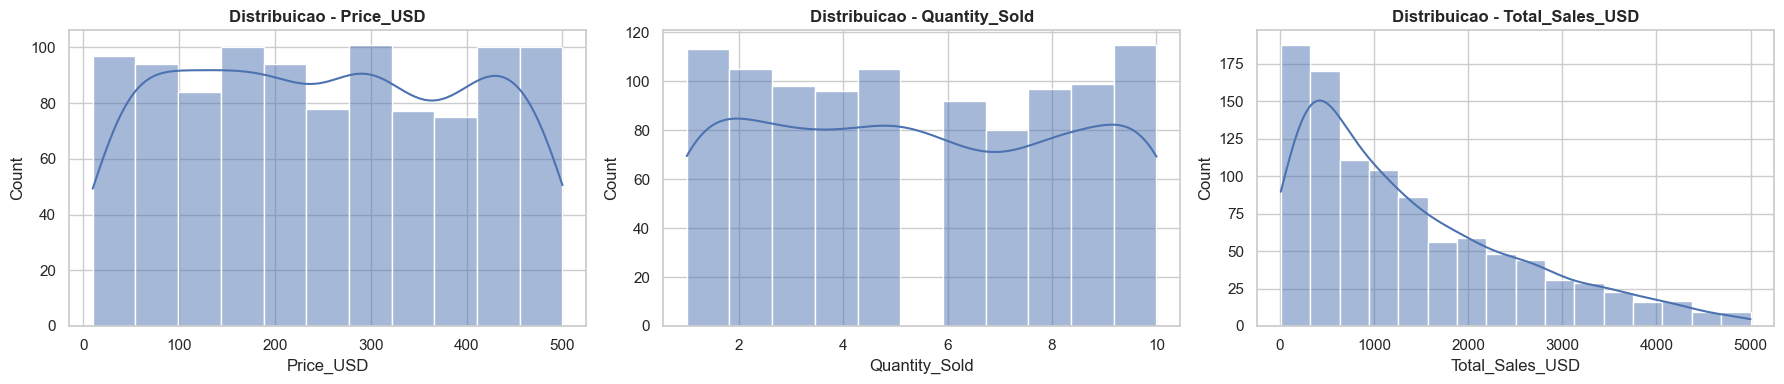

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, ["Price_USD", "Quantity_Sold", "Total_Sales_USD"]):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribuicao - {col}")
plt.tight_layout()

## 6. Analise temporal

A futura aplicacao deve acompanhar tendencia, sazonalidade, variacao mensal e desvios recentes. Para modelagem preditiva, esta tambem e a base para features temporais.

In [10]:
monthly_sales = (
    df.groupby("Year_Month", as_index=False)
    .agg(
        revenue=("Total_Sales_USD", "sum"),
        units=("Quantity_Sold", "sum"),
        orders=("Product_ID", "count"),
        avg_ticket=("Total_Sales_USD", "mean"),
    )
    .sort_values("Year_Month")
)
monthly_sales["revenue_mom_pct"] = monthly_sales["revenue"].pct_change() * 100
monthly_sales["units_mom_pct"] = monthly_sales["units"].pct_change() * 100
monthly_sales

,Year_Month,revenue,units,orders,avg_ticket,revenue_mom_pct,units_mom_pct
0,2025-01-01,84241,343,59,"1,427.81",NaN,NaN
1,2025-02-01,90810,347,56,"1,621.61",7.80,1.17
2,2025-03-01,84380,322,59,"1,430.17",-7.08,-7.20
3,2025-04-01,77831,316,51,"1,526.10",-7.76,-1.86
4,2025-05-01,88174,338,63,"1,399.59",13.29,6.96
5,2025-06-01,79293,360,63,"1,258.62",-10.07,6.51
6,2025-07-01,72214,294,57,"1,266.91",-8.93,-18.33
7,2025-08-01,101723,397,66,"1,541.26",40.86,35.03
8,2025-09-01,81216,338,66,"1,230.55",-20.16,-14.86
9,2025-10-01,92946,348,65,"1,429.94",14.44,2.96


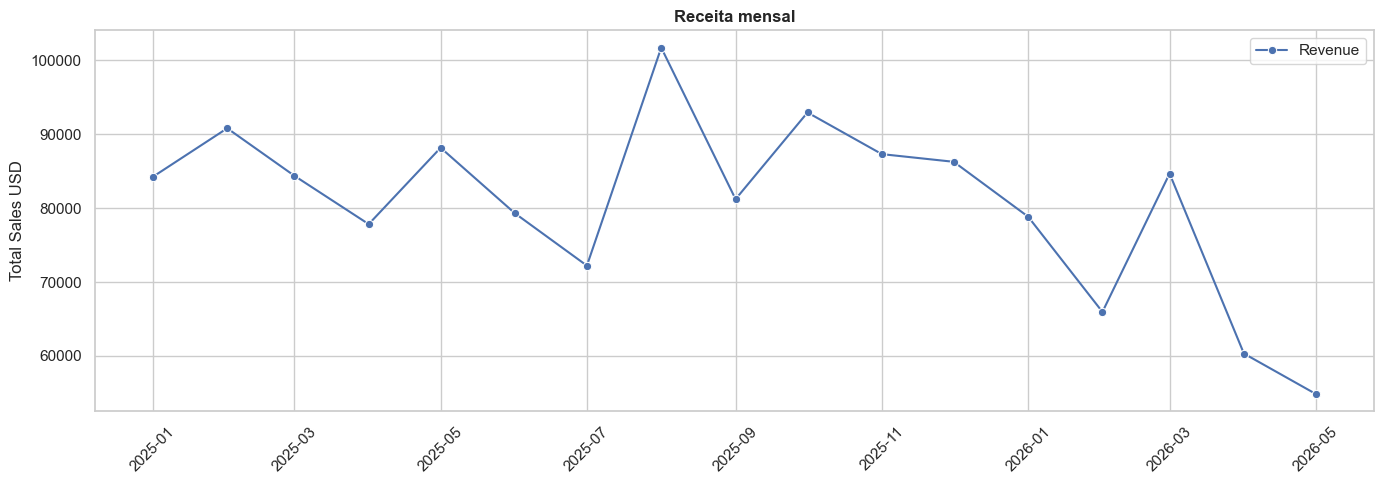

In [11]:
fig, ax1 = plt.subplots(figsize=(14, 5))
sns.lineplot(data=monthly_sales, x="Year_Month", y="revenue", marker="o", ax=ax1, label="Revenue")
ax1.set_title("Receita mensal")
ax1.set_xlabel("")
ax1.set_ylabel("Total Sales USD")
ax1.tick_params(axis="x", rotation=45)
plt.tight_layout()

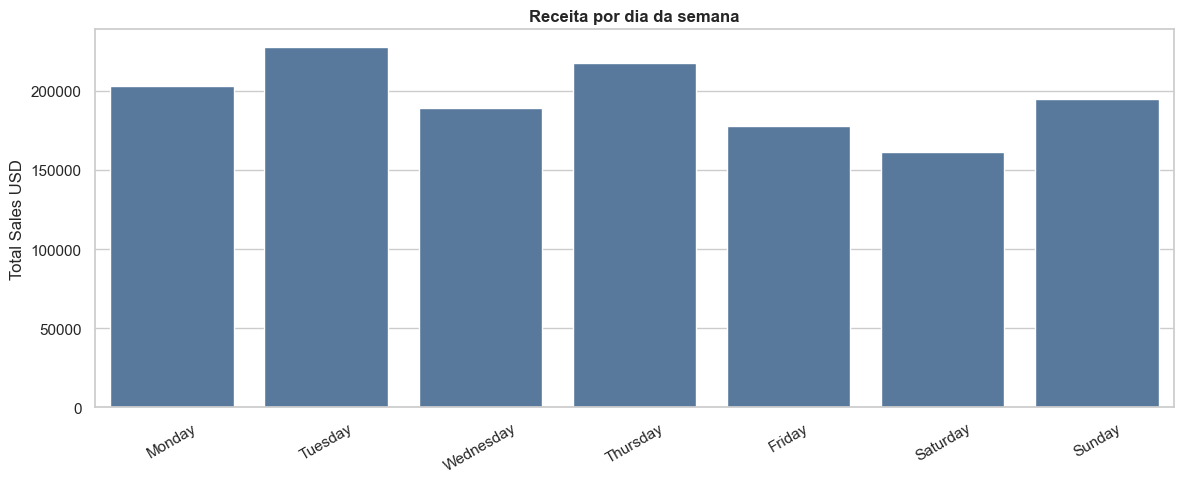

In [12]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_sales = (
    df.groupby("Day_Of_Week", as_index=False)
    .agg(revenue=("Total_Sales_USD", "sum"), units=("Quantity_Sold", "sum"), orders=("Product_ID", "count"))
)
dow_sales["Day_Of_Week"] = pd.Categorical(dow_sales["Day_Of_Week"], categories=dow_order, ordered=True)
dow_sales = dow_sales.sort_values("Day_Of_Week")

sns.barplot(data=dow_sales, x="Day_Of_Week", y="revenue", color="#4C78A8")
plt.title("Receita por dia da semana")
plt.xlabel("")
plt.ylabel("Total Sales USD")
plt.xticks(rotation=30)
plt.tight_layout()

## 7. Categorias, produtos e cidades

In [13]:
def summarize_dimension(dim):
    out = (
        df.groupby(dim, as_index=False)
        .agg(
            revenue=("Total_Sales_USD", "sum"),
            units=("Quantity_Sold", "sum"),
            orders=("Product_ID", "count"),
            avg_price=("Price_USD", "mean"),
            avg_ticket=("Total_Sales_USD", "mean"),
        )
        .sort_values("revenue", ascending=False)
    )
    out["revenue_share_pct"] = out["revenue"] / out["revenue"].sum() * 100
    out["unit_share_pct"] = out["units"] / out["units"].sum() * 100
    return out

category_summary = summarize_dimension("Category")
product_summary = summarize_dimension("Product_Name")
city_summary = summarize_dimension("Customer_City")

category_summary

,Category,revenue,units,orders,avg_price,avg_ticket,revenue_share_pct,unit_share_pct
5,Sports,310674,1106,196,278.69,"1,585.07",22.66,20.27
0,Beauty,249665,958,180,260.51,"1,387.03",18.21,17.56
4,Home,233891,917,160,250.04,"1,461.82",17.06,16.81
1,Books,202704,942,167,231.22,"1,213.80",14.78,17.27
3,Fashion,200854,804,159,250.86,"1,263.23",14.65,14.74
2,Electronics,173244,728,138,244.46,"1,255.39",12.64,13.35


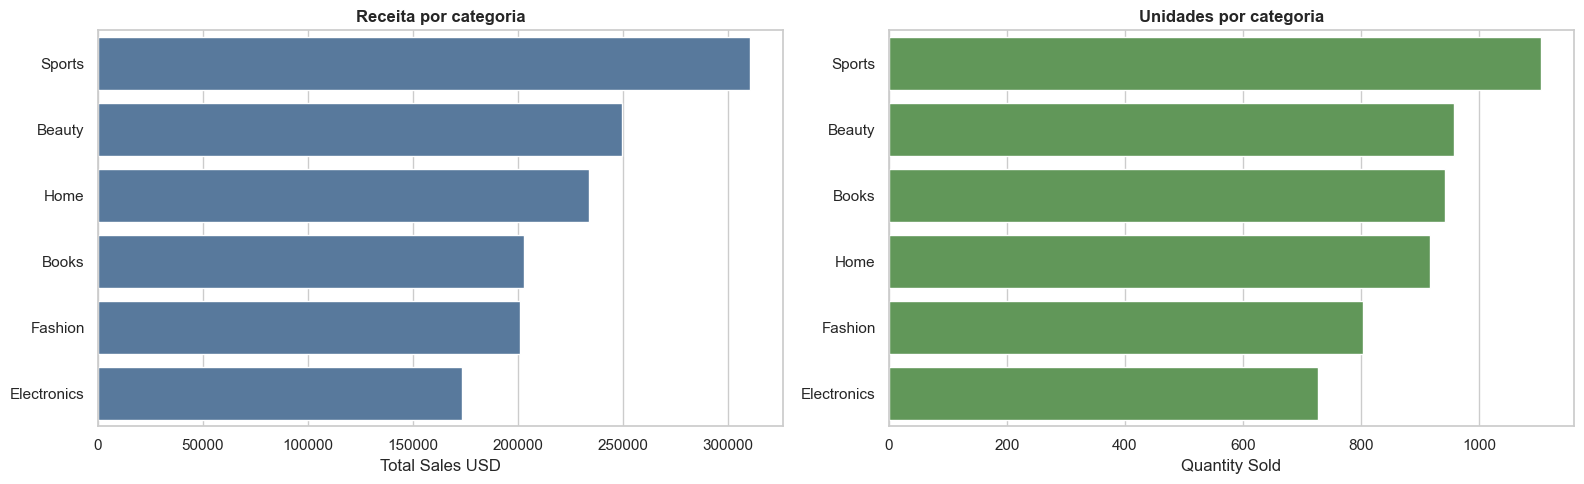

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=category_summary, y="Category", x="revenue", ax=axes[0], color="#4C78A8")
axes[0].set_title("Receita por categoria")
axes[0].set_xlabel("Total Sales USD")
axes[0].set_ylabel("")

sns.barplot(data=category_summary.sort_values("units", ascending=False), y="Category", x="units", ax=axes[1], color="#59A14F")
axes[1].set_title("Unidades por categoria")
axes[1].set_xlabel("Quantity Sold")
axes[1].set_ylabel("")
plt.tight_layout()

,Product_Name,revenue,units,orders,avg_price,avg_ticket,revenue_share_pct,unit_share_pct
22,Tennis Ball,96227,330,56,284.79,"1,718.34",7.02,6.05
5,Gym Gloves,80127,281,51,275.63,"1,571.12",5.84,5.15
21,Table,74455,283,46,255.61,"1,618.59",5.43,5.19
12,Lipstick,72172,256,49,275.49,"1,472.90",5.26,4.69
3,Face Wash,70936,258,46,270.33,"1,542.09",5.17,4.73
4,Football,67989,243,42,288.40,"1,618.79",4.96,4.45
2,Cricket Bat,66331,252,47,266.09,"1,411.30",4.84,4.62
9,Jeans,65260,240,43,269.98,"1,517.67",4.76,4.40
1,Coffee Mug,59260,245,41,239.07,"1,445.37",4.32,4.49
19,Smart Watch,59069,196,32,295.25,"1,845.91",4.31,3.59


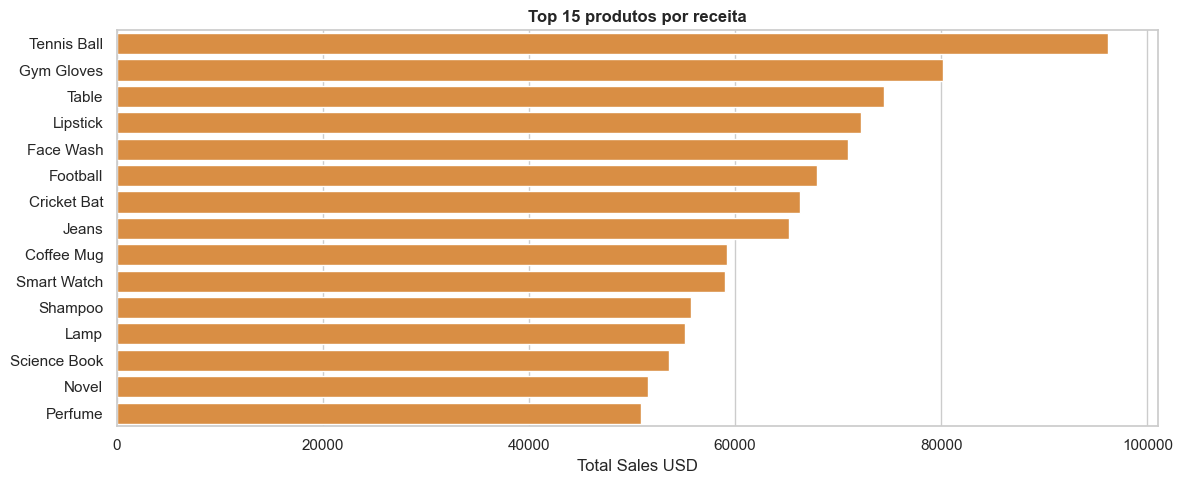

In [15]:
top_products = product_summary.head(15)
sns.barplot(data=top_products, y="Product_Name", x="revenue", color="#F28E2B")
plt.title("Top 15 produtos por receita")
plt.xlabel("Total Sales USD")
plt.ylabel("")
plt.tight_layout()
top_products

,Customer_City,revenue,units,orders,avg_price,avg_ticket,revenue_share_pct,unit_share_pct
3,Peshawar,284654,1166,211,240.73,"1,349.07",20.76,21.37
0,Islamabad,281637,1155,219,248.87,"1,286.01",20.54,21.17
2,Lahore,271491,1066,190,259.21,"1,428.90",19.80,19.54
1,Karachi,269551,1032,182,263.76,"1,481.05",19.66,18.92
4,Quetta,263699,1036,198,258.62,"1,331.81",19.23,18.99


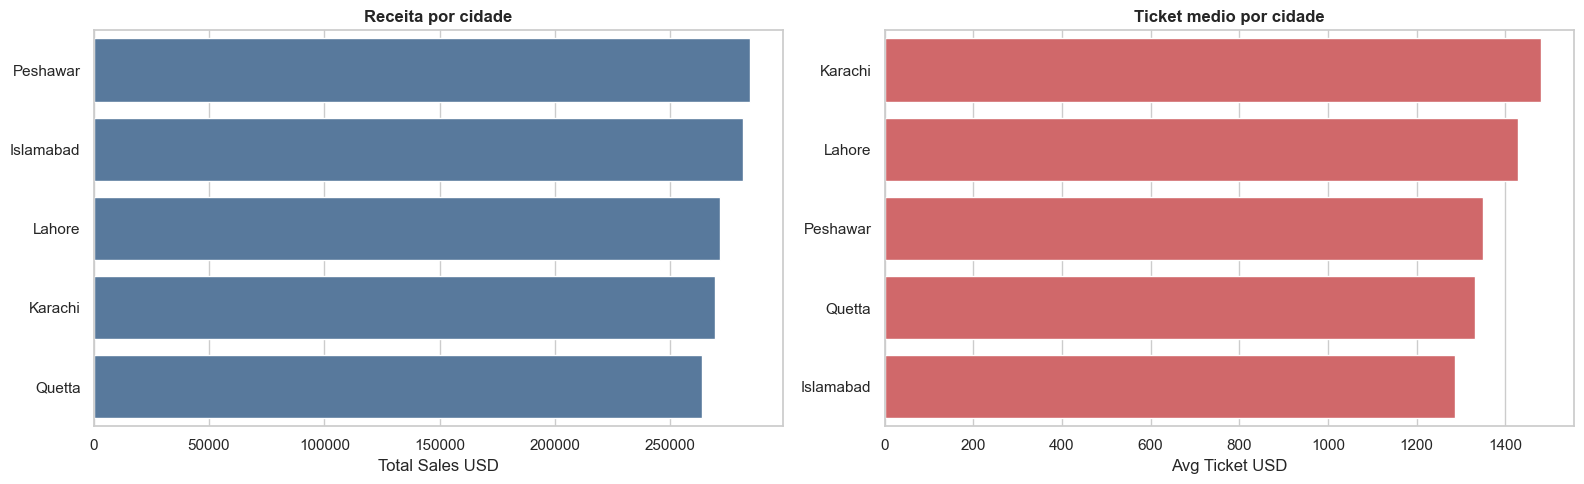

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=city_summary, y="Customer_City", x="revenue", ax=axes[0], color="#4C78A8")
axes[0].set_title("Receita por cidade")
axes[0].set_xlabel("Total Sales USD")
axes[0].set_ylabel("")

sns.barplot(data=city_summary.sort_values("avg_ticket", ascending=False), y="Customer_City", x="avg_ticket", ax=axes[1], color="#E15759")
axes[1].set_title("Ticket medio por cidade")
axes[1].set_xlabel("Avg Ticket USD")
axes[1].set_ylabel("")
plt.tight_layout()
city_summary

## 8. Mix categoria x cidade

Este corte ajuda a identificar concentracao geografica, oportunidades de sortimento e segmentos que podem entrar no painel de monitoramento.

Customer_City,Islamabad,Karachi,Lahore,Peshawar,Quetta
Category,,,,,
Beauty,50654,47979,46213,50709,54110
Books,52251,29879,44417,36962,39195
Electronics,37460,37942,34477,30181,33184
Fashion,32973,44564,34308,50512,38497
Home,39486,53553,39400,54903,46549
Sports,68813,55634,72676,61387,52164


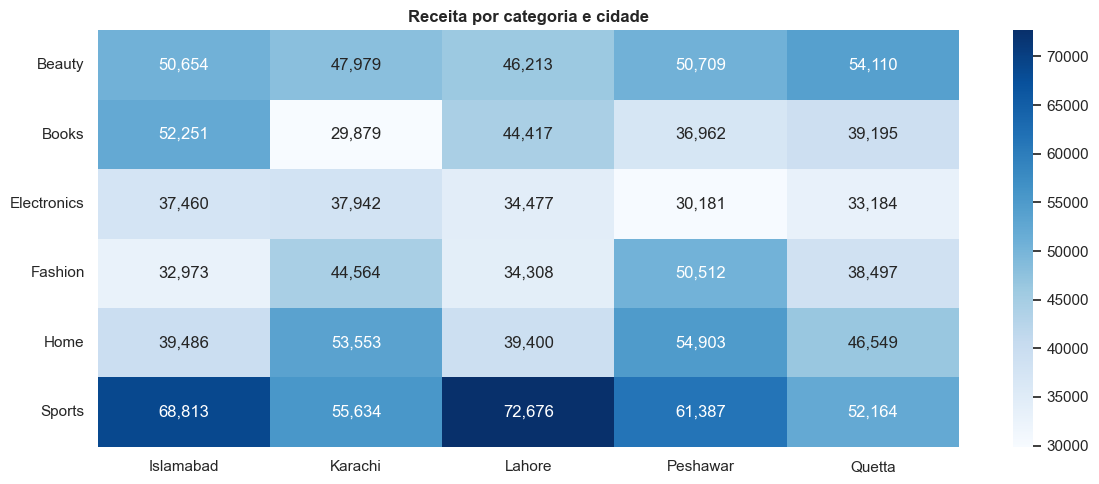

In [17]:
category_city_revenue = pd.pivot_table(
    df,
    values="Total_Sales_USD",
    index="Category",
    columns="Customer_City",
    aggfunc="sum",
    fill_value=0,
)

sns.heatmap(category_city_revenue, annot=True, fmt=",.0f", cmap="Blues")
plt.title("Receita por categoria e cidade")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
category_city_revenue

## 9. Concentracao e curva ABC

A curva ABC ajuda a separar produtos/categorias que merecem monitoramento prioritario. Para recomendacao, produtos A tendem a ser candidatos fortes; produtos B/C podem precisar de contexto, margem, estoque ou complementaridade.

In [18]:
abc_products = product_summary.copy()
abc_products["cum_revenue"] = abc_products["revenue"].cumsum()
abc_products["cum_revenue_pct"] = abc_products["cum_revenue"] / abc_products["revenue"].sum() * 100
abc_products["abc_class"] = np.select(
    [abc_products["cum_revenue_pct"] <= 80, abc_products["cum_revenue_pct"] <= 95],
    ["A", "B"],
    default="C",
)

abc_summary = abc_products.groupby("abc_class", as_index=False).agg(
    products=("Product_Name", "count"),
    revenue=("revenue", "sum"),
    units=("units", "sum"),
)
abc_summary["revenue_share_pct"] = abc_summary["revenue"] / abc_summary["revenue"].sum() * 100
abc_summary

,abc_class,products,revenue,units,revenue_share_pct
0,A,17,1078139,4119,78.64
1,B,4,185891,808,13.56
2,C,3,107002,528,7.80


,Product_Name,revenue,units,orders,avg_price,avg_ticket,revenue_share_pct,unit_share_pct,cum_revenue,cum_revenue_pct,abc_class
22,Tennis Ball,96227,330,56,284.79,"1,718.34",7.02,6.05,96227,7.02,A
5,Gym Gloves,80127,281,51,275.63,"1,571.12",5.84,5.15,176354,12.86,A
21,Table,74455,283,46,255.61,"1,618.59",5.43,5.19,250809,18.29,A
12,Lipstick,72172,256,49,275.49,"1,472.90",5.26,4.69,322981,23.56,A
3,Face Wash,70936,258,46,270.33,"1,542.09",5.17,4.73,393917,28.73,A
4,Football,67989,243,42,288.40,"1,618.79",4.96,4.45,461906,33.69,A
2,Cricket Bat,66331,252,47,266.09,"1,411.30",4.84,4.62,528237,38.53,A
9,Jeans,65260,240,43,269.98,"1,517.67",4.76,4.40,593497,43.29,A
1,Coffee Mug,59260,245,41,239.07,"1,445.37",4.32,4.49,652757,47.61,A
19,Smart Watch,59069,196,32,295.25,"1,845.91",4.31,3.59,711826,51.92,A


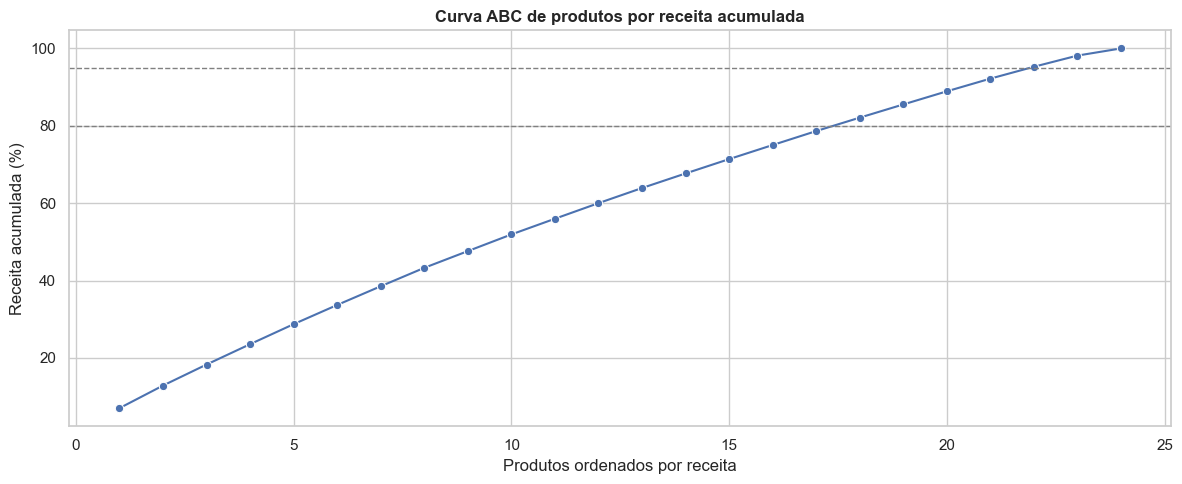

In [19]:
sns.lineplot(data=abc_products, x=np.arange(1, len(abc_products) + 1), y="cum_revenue_pct", marker="o")
plt.axhline(80, linestyle="--", color="gray", linewidth=1)
plt.axhline(95, linestyle="--", color="gray", linewidth=1)
plt.title("Curva ABC de produtos por receita acumulada")
plt.xlabel("Produtos ordenados por receita")
plt.ylabel("Receita acumulada (%)")
plt.tight_layout()
abc_products.head(20)

## 10. Relacao preco, volume e receita

,Price_USD,Quantity_Sold,Total_Sales_USD
Price_USD,1.00,-0.03,0.67
Quantity_Sold,-0.03,1.00,0.63
Total_Sales_USD,0.67,0.63,1.00


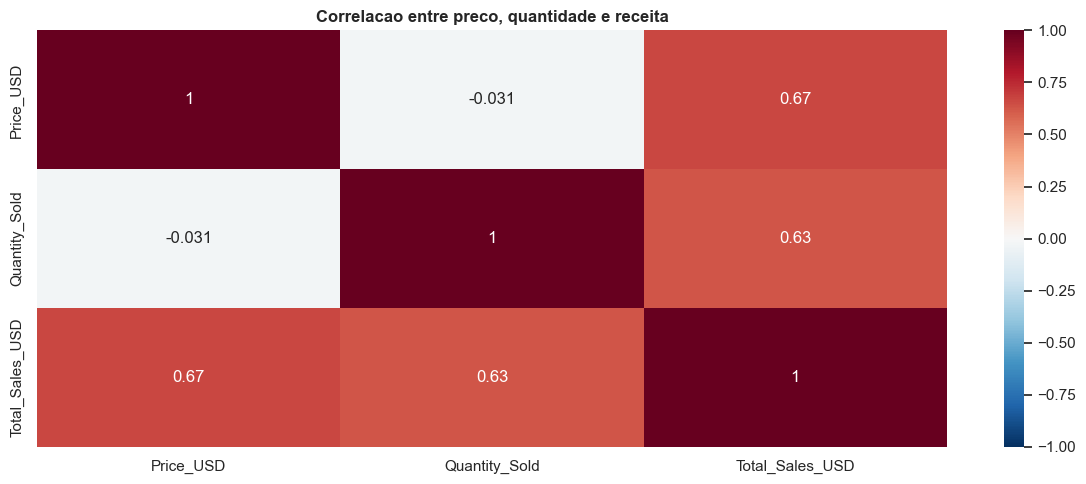

In [20]:
corr_cols = ["Price_USD", "Quantity_Sold", "Total_Sales_USD"]
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="RdBu_r", vmin=-1, vmax=1)
plt.title("Correlacao entre preco, quantidade e receita")
plt.tight_layout()
corr_matrix

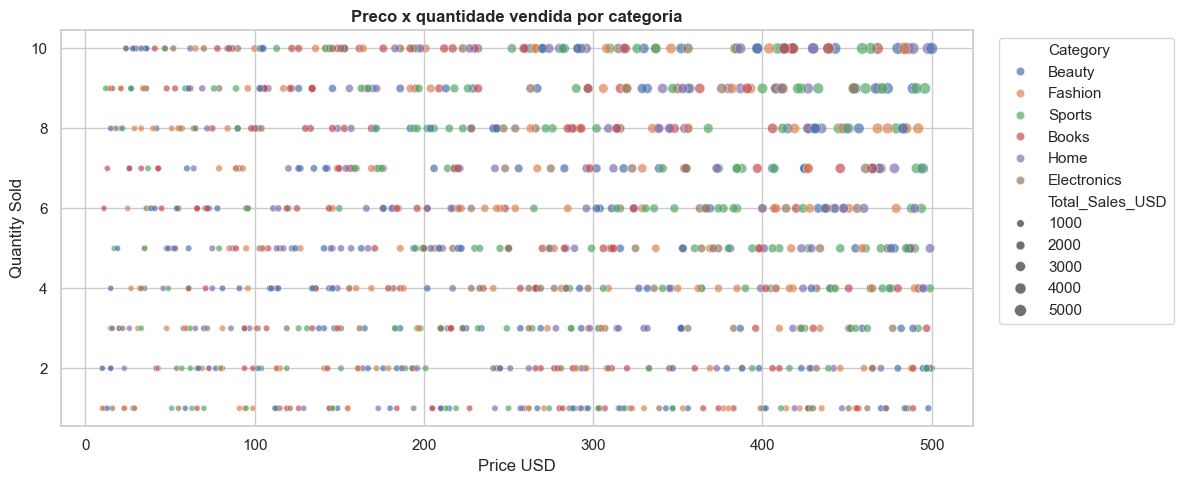

In [21]:
sns.scatterplot(data=df, x="Price_USD", y="Quantity_Sold", hue="Category", size="Total_Sales_USD", alpha=0.7)
plt.title("Preco x quantidade vendida por categoria")
plt.xlabel("Price USD")
plt.ylabel("Quantity Sold")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

## 11. Outliers e pontos de atencao

In [22]:
def iqr_outliers(data, col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return data[(data[col] < lower) | (data[col] > upper)].copy(), lower, upper

outlier_tables = {}
for col in ["Price_USD", "Quantity_Sold", "Total_Sales_USD"]:
    outliers, lower, upper = iqr_outliers(df, col)
    outlier_tables[col] = {"count": len(outliers), "lower_bound": lower, "upper_bound": upper}

pd.DataFrame(outlier_tables).T

,count,lower_bound,upper_bound
Price_USD,0.00,-258.00,768.00
Quantity_Sold,0.00,-4.50,15.50
Total_Sales_USD,18.00,"-1,945.00","4,377.00"


In [23]:
df.nlargest(15, "Total_Sales_USD")[[
    "Order_Date", "Product_Name", "Category", "Customer_City", "Price_USD", "Quantity_Sold", "Total_Sales_USD"
]]

,Order_Date,Product_Name,Category,Customer_City,Price_USD,Quantity_Sold,Total_Sales_USD
449,2025-04-02,Face Wash,Beauty,Quetta,500,10,5000
301,2026-03-14,Coffee Mug,Home,Lahore,498,10,4980
617,2026-03-03,Coffee Mug,Home,Karachi,489,10,4890
590,2025-04-21,Lipstick,Beauty,Peshawar,486,10,4860
232,2025-12-18,Shoes,Fashion,Quetta,485,10,4850
545,2025-12-15,Jacket,Fashion,Karachi,484,10,4840
708,2025-07-13,Shoes,Fashion,Karachi,484,10,4840
153,2025-03-10,Gym Gloves,Sports,Quetta,483,10,4830
550,2026-05-05,Perfume,Beauty,Peshawar,480,10,4800
152,2025-11-16,Novel,Books,Lahore,468,10,4680


## 12. Sinais para aplicacao, previsao e recomendacao

### KPIs recomendados para monitoramento

- Receita total, unidades vendidas, pedidos/linhas e ticket medio.
- Receita por mes, variacao mensal e media movel.
- Receita e unidades por categoria, produto e cidade.
- Top produtos por receita e por volume.
- Participacao de receita por categoria/cidade.
- Alertas de queda mensal, produtos sem venda recente e concentracao excessiva.

### Features candidatas para previsao

- Features temporais: mes, trimestre, dia da semana, feriados/calendario local quando disponivel.
- Agregacoes defasadas: vendas do mes anterior, media movel de 3/6 meses, variacao percentual.
- Hierarquias: previsao global, por categoria, por produto e por cidade.
- Preco medio e mudancas de preco por produto/categoria.

### Recomendacao de produtos

- Ranking por receita e volume como baseline simples.
- Recomendacoes por cidade e categoria com base em afinidade historica.
- No futuro, enriquecer a base com cliente, carrinho/pedido, margem, estoque e visualizacoes para permitir recomendacao colaborativa ou baseada em associacao.

## 13. Tabelas finais para reutilizacao

Estas tabelas podem virar fontes diretas para uma camada `processed` ou para uma API/dashboard inicial.

In [24]:
display(kpis)
display(monthly_sales.tail(12))
display(category_summary)
display(city_summary)
display(abc_products.head(20))

,KPI,Valor
0,Revenue total,"1,371,032.00"
1,Unidades vendidas,"5,455.00"
2,Pedidos/linhas,"1,000.00"
3,Ticket medio,"1,371.03"
4,Preco medio realizado,251.33
5,Produtos unicos,24.00
6,Categorias,6.00
7,Cidades,5.00
8,Receita media diaria,"2,742.06"
9,Unidades medias diarias,10.91


,Year_Month,revenue,units,orders,avg_ticket,revenue_mom_pct,units_mom_pct
5,2025-06-01,79293,360,63,"1,258.62",-10.07,6.51
6,2025-07-01,72214,294,57,"1,266.91",-8.93,-18.33
7,2025-08-01,101723,397,66,"1,541.26",40.86,35.03
8,2025-09-01,81216,338,66,"1,230.55",-20.16,-14.86
9,2025-10-01,92946,348,65,"1,429.94",14.44,2.96
10,2025-11-01,87310,364,66,"1,322.88",-6.06,4.60
11,2025-12-01,86270,320,61,"1,414.26",-1.19,-12.09
12,2026-01-01,78844,318,62,"1,271.68",-8.61,-0.62
13,2026-02-01,65951,257,53,"1,244.36",-16.35,-19.18
14,2026-03-01,84676,381,76,"1,114.16",28.39,48.25


,Category,revenue,units,orders,avg_price,avg_ticket,revenue_share_pct,unit_share_pct
5,Sports,310674,1106,196,278.69,"1,585.07",22.66,20.27
0,Beauty,249665,958,180,260.51,"1,387.03",18.21,17.56
4,Home,233891,917,160,250.04,"1,461.82",17.06,16.81
1,Books,202704,942,167,231.22,"1,213.80",14.78,17.27
3,Fashion,200854,804,159,250.86,"1,263.23",14.65,14.74
2,Electronics,173244,728,138,244.46,"1,255.39",12.64,13.35


,Customer_City,revenue,units,orders,avg_price,avg_ticket,revenue_share_pct,unit_share_pct
3,Peshawar,284654,1166,211,240.73,"1,349.07",20.76,21.37
0,Islamabad,281637,1155,219,248.87,"1,286.01",20.54,21.17
2,Lahore,271491,1066,190,259.21,"1,428.90",19.80,19.54
1,Karachi,269551,1032,182,263.76,"1,481.05",19.66,18.92
4,Quetta,263699,1036,198,258.62,"1,331.81",19.23,18.99


,Product_Name,revenue,units,orders,avg_price,avg_ticket,revenue_share_pct,unit_share_pct,cum_revenue,cum_revenue_pct,abc_class
22,Tennis Ball,96227,330,56,284.79,"1,718.34",7.02,6.05,96227,7.02,A
5,Gym Gloves,80127,281,51,275.63,"1,571.12",5.84,5.15,176354,12.86,A
21,Table,74455,283,46,255.61,"1,618.59",5.43,5.19,250809,18.29,A
12,Lipstick,72172,256,49,275.49,"1,472.90",5.26,4.69,322981,23.56,A
3,Face Wash,70936,258,46,270.33,"1,542.09",5.17,4.73,393917,28.73,A
4,Football,67989,243,42,288.40,"1,618.79",4.96,4.45,461906,33.69,A
2,Cricket Bat,66331,252,47,266.09,"1,411.30",4.84,4.62,528237,38.53,A
9,Jeans,65260,240,43,269.98,"1,517.67",4.76,4.40,593497,43.29,A
1,Coffee Mug,59260,245,41,239.07,"1,445.37",4.32,4.49,652757,47.61,A
19,Smart Watch,59069,196,32,295.25,"1,845.91",4.31,3.59,711826,51.92,A
